# XGBoost Return Forecasting — All 3 Models

Trains and evaluates three XGBoost models that forecast each coin's **7-day-ahead price** on the test set. Each model is trained independently per coin (8 coins total). Forecasts are evaluated at each 7-day rebalance step and outputs are consumed by CMVO for portfolio optimisation.

---

## Models

### Model 1 — XGBoost Base
- **Features:** 14 lagged close prices
- **Target:** Close price 7 days ahead (direct price prediction)
- **Split:** 80/20 train/test
- **Hyperparameters:** Fixed (`n_estimators=300`, `max_depth=6`, `lr=0.05`)
- **Output:** `xgboost_forecasts.csv`, RMSE1_normalized.csv`

### Model 2 — XGBoost Features
- **Features:** 14 lagged log returns + 30/60-day rolling volatility (lagged)
- **Target:** Log return 7 days ahead → converted back to price
- **Split:** 80/20 train/test
- **Hyperparameters:** Fixed (same as Base)
- **Output:** `xgb_feature_forecasts.csv`, `xgb_feature_rmses.csv`

### Model 3 — XGBoost Bayesian Optimised (BO)
- **Features:** 14 lagged close prices + 7-day rolling volatility
- **Target:** Close price 7 days ahead
- **Split:** 60/20/20 train/val/test
- **Hyperparameters:** Tuned with Optuna (30 trials, minimising val RMSE)
- **Output:** `xgboost_forecasts_BO_price_vol.csv`, `xgboost_rmse_summary_BO_price_vol.csv`

---

**Note:** Output CSVs are saved to the notebook's working directory. Tiny-price coins (median < 0.01) are log-transformed before training and inverse-transformed for evaluation.

In [1]:
import os
print(os.listdir("klines csv data/prices_cleaned"))

['ADAUSDT', 'BCHUSDT', 'BNBUSDT', 'BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'TRXUSDT', 'XRPUSDT']


## Model 1 — XGBoost Base


Training: ADAUSDT
ADAUSDT RMSE: 0.160889
ADAUSDT Mean Actual Price: 0.528646
ADAUSDT NRMSE (% of mean price): 0.3043%


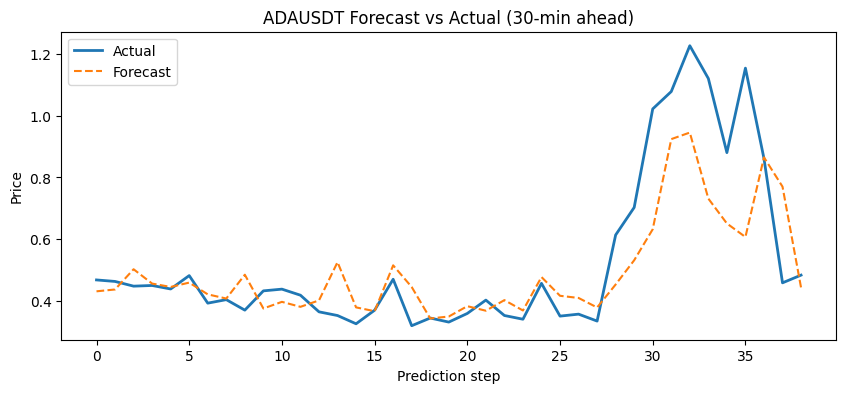


Training: BCHUSDT
BCHUSDT RMSE: 88.484263
BCHUSDT Mean Actual Price: 367.982051
BCHUSDT NRMSE (% of mean price): 0.2405%


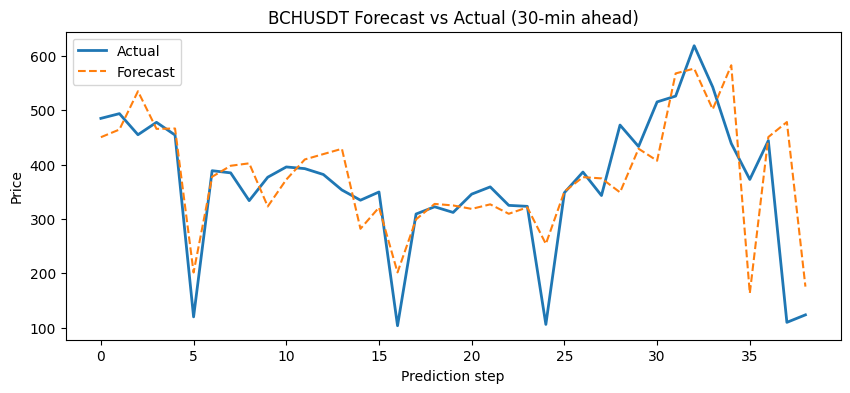


Training: BNBUSDT
BNBUSDT RMSE: 91.077701
BNBUSDT Mean Actual Price: 545.711282
BNBUSDT NRMSE (% of mean price): 0.1669%


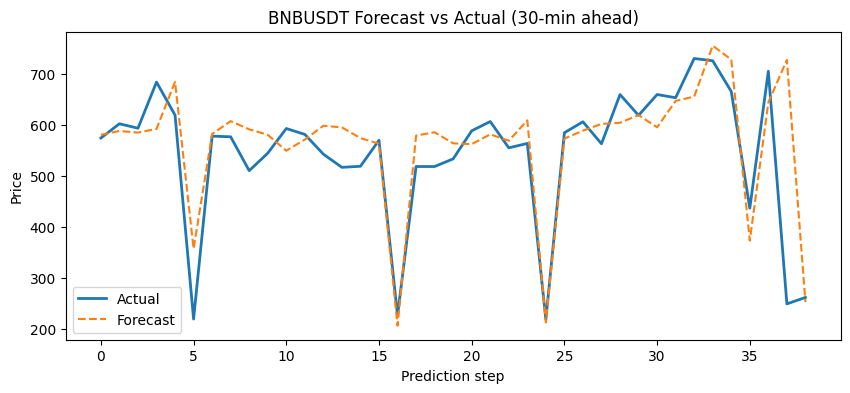


Training: BTCUSDT
BTCUSDT RMSE: 14863.288045
BTCUSDT Mean Actual Price: 64286.045128
BTCUSDT NRMSE (% of mean price): 0.2312%


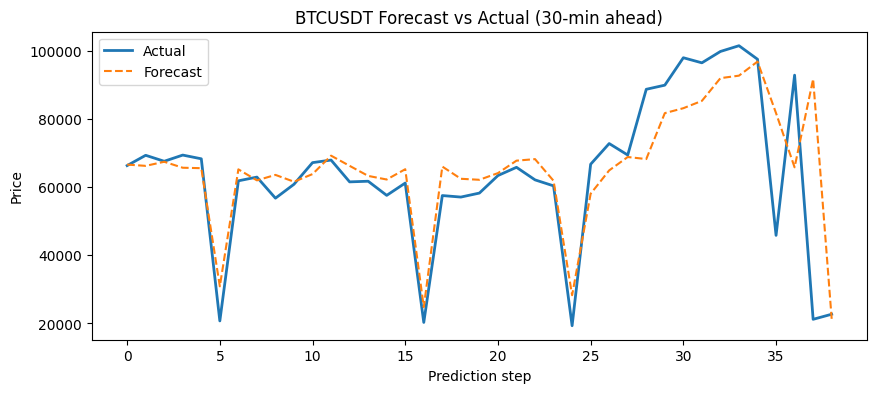


Training: ETHUSDT
ETHUSDT RMSE: 543.011128
ETHUSDT Mean Actual Price: 2851.582564
ETHUSDT NRMSE (% of mean price): 0.1904%


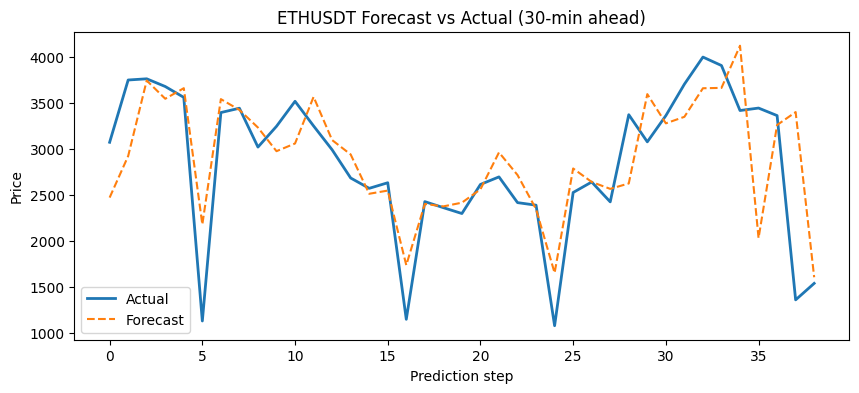


Training: SOLUSDT
SOLUSDT RMSE: 32.606461
SOLUSDT Mean Actual Price: 152.974615
SOLUSDT NRMSE (% of mean price): 0.2131%


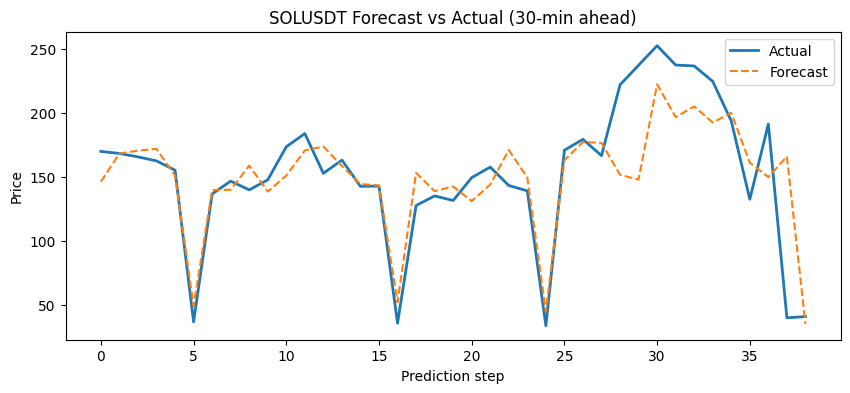


Training: TRXUSDT
TRXUSDT RMSE: 0.056930
TRXUSDT Mean Actual Price: 0.147867
TRXUSDT NRMSE (% of mean price): 0.3850%


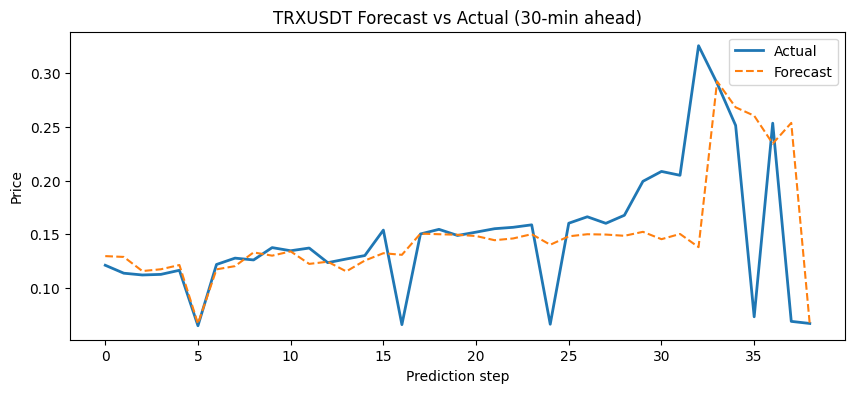


Training: XRPUSDT
XRPUSDT RMSE: 0.490586
XRPUSDT Mean Actual Price: 0.774849
XRPUSDT NRMSE (% of mean price): 0.6331%


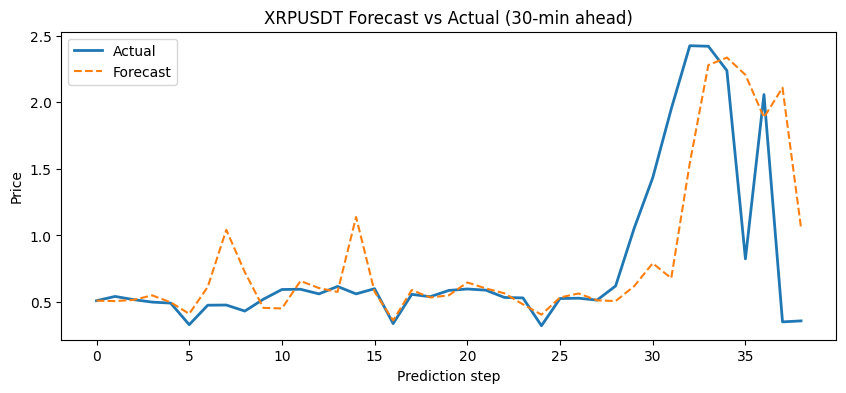

,coin,actual,forecast
0,ADAUSDT,0.4672,0.430223
1,ADAUSDT,0.4623,0.436188
2,ADAUSDT,0.4470,0.501902
3,ADAUSDT,0.4492,0.455375
4,ADAUSDT,0.4378,0.444392
...,...,...,...
307,XRPUSDT,2.2390,2.336861
308,XRPUSDT,0.8240,2.206910
309,XRPUSDT,2.0587,1.886836
310,XRPUSDT,0.3505,2.110292



RMSE Summary


,RMSE,Mean_Actual_Price,NRMSE_Mean,NRMSE_Percent
BNBUSDT,91.077701,545.711282,0.166897,0.166897
ETHUSDT,543.011128,2851.582564,0.190424,0.190424
SOLUSDT,32.606461,152.974615,0.213149,0.213149
BTCUSDT,14863.288045,64286.045128,0.231206,0.231206
BCHUSDT,88.484263,367.982051,0.240458,0.240458
ADAUSDT,0.160889,0.528646,0.304341,0.304341
TRXUSDT,0.056930,0.147867,0.385008,0.385008
XRPUSDT,0.490586,0.774849,0.633138,0.633138


In [2]:

import pandas as pd
import numpy as np
import xgboost as xgb
import os
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

#lags to be 2xhorizon, so 2x30 because 30 minutes
data_folder = "klines csv data/prices_cleaned"
HORIZON = 7
N_LAGS = 14

results = {}
all_tables = []

#table of lags
def create_lags(df, n_lags):
    for i in range(1, n_lags + 1):
        df[f"lag_{i}"] = df["close"].shift(i)
    return df

#total files
files = os.listdir(data_folder)

#looping through coins
for file in files:

    if file.startswith("."):
        continue

    coin = file.replace(".csv","")
    print("\nTraining:", coin)

    path = os.path.join(data_folder, file)

    df = pd.read_csv(path, header=None)
    df.columns = ["index","close","time"]

    # ensure numeric just in case
    df["close"] = pd.to_numeric(df["close"], errors="coerce")

    # ensuring chronological order, just in case
    df = df.sort_values("time")

    df = df[["close"]]


    # Handle tiny-price coins

    tiny_price = df["close"].median() < 0.01

    if tiny_price:
        print("Tiny price detected → using log price")
        df["close"] = np.log(df["close"])

    df["target"] = df["close"].shift(-HORIZON)

    df = create_lags(df, N_LAGS)

    df = df.dropna().reset_index(drop=True)

    #train test split
    X = df.drop(columns=["target"])
    y = df["target"]

    split = int(len(df) * 0.8)

    X_train = X.iloc[:split]
    X_test = X.iloc[split:]

    y_train = y.iloc[:split]
    y_test = y.iloc[split:]

    # Model
    model = xgb.XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    )

    model.fit(X_train, y_train)

    #predict
    preds = []
    actual = []

    for i in range(0, len(X_test), 7):

        if i >= len(X_test):
            break

        pred = model.predict(X_test.iloc[i:i+1])[0]

        if tiny_price:
            preds.append(np.exp(pred))
            actual.append(np.exp(y_test.iloc[i]))
        else:
            preds.append(pred)
            actual.append(y_test.iloc[i])

    preds = np.array(preds)
    actual = np.array(actual)

    # raw RMSE
    rmse = np.sqrt(mean_squared_error(actual, preds))

    # NEW: normalize by mean actual price
    mean_actual_price = actual.mean()
    nrmse_mean = rmse / mean_actual_price
    nrmse_pct = nrmse_mean

    results[coin] = {
        "RMSE": rmse,
        "Mean_Actual_Price": mean_actual_price,
        "NRMSE_Mean": nrmse_mean,
        "NRMSE_Percent": nrmse_pct
    }

    print(f"{coin} RMSE: {rmse:.6f}")
    print(f"{coin} Mean Actual Price: {mean_actual_price:.6f}")
    print(f"{coin} NRMSE (% of mean price): {nrmse_pct:.4f}%")

    # Ssave table
    table = pd.DataFrame({
        "coin": coin,
        "actual": actual,
        "forecast": preds
    })

    all_tables.append(table)

    # Plot
    plt.figure(figsize=(10,4))
    plt.plot(actual, label="Actual", linewidth=2)
    plt.plot(preds, label="Forecast", linestyle="--")
    plt.title(f"{coin} Forecast vs Actual (30-min ahead)")
    plt.xlabel("Prediction step")
    plt.ylabel("Price")
    plt.legend()
    plt.show()

#final table
final_table = pd.concat(all_tables, ignore_index=True)

display(final_table)

# save predictions
final_table.to_csv("12 XGBoost results/xgboost_forecasts.csv", index=False)

#rmse summary
rmse_table = pd.DataFrame.from_dict(results, orient="index")
rmse_table = rmse_table.sort_values("NRMSE_Percent")

rmse_table.to_csv("12 XGBoost results/RMSE1_normalized.csv", index=True)

print("\nRMSE Summary")
display(rmse_table)

## Model 2 — XGBoost Features

c:\Users\ameli\Documents\all ur code projects\optimising-dynamic-crypto-portfolio\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Files detected: 8
['ADAUSDT', 'BCHUSDT', 'BNBUSDT', 'BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'TRXUSDT', 'XRPUSDT']

Training: ADAUSDT
ADAUSDT RMSE: 0.23214559937900137


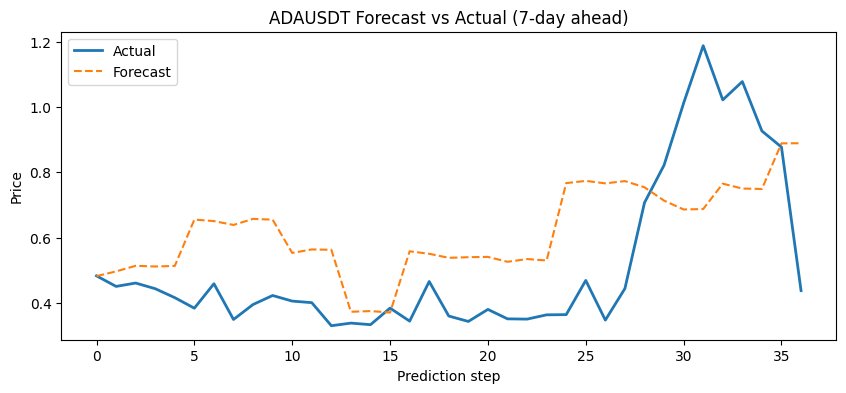


Training: BCHUSDT
BCHUSDT RMSE: 197.0139674373993


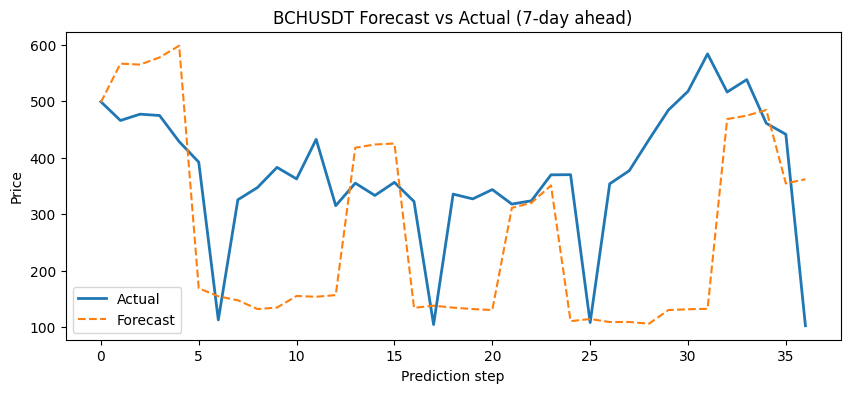


Training: BNBUSDT
BNBUSDT RMSE: 285.7360054027656


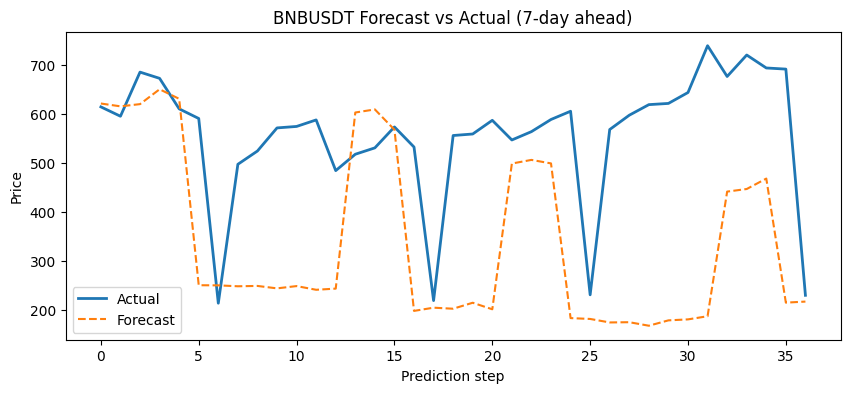


Training: BTCUSDT
BTCUSDT RMSE: 36116.49196802857


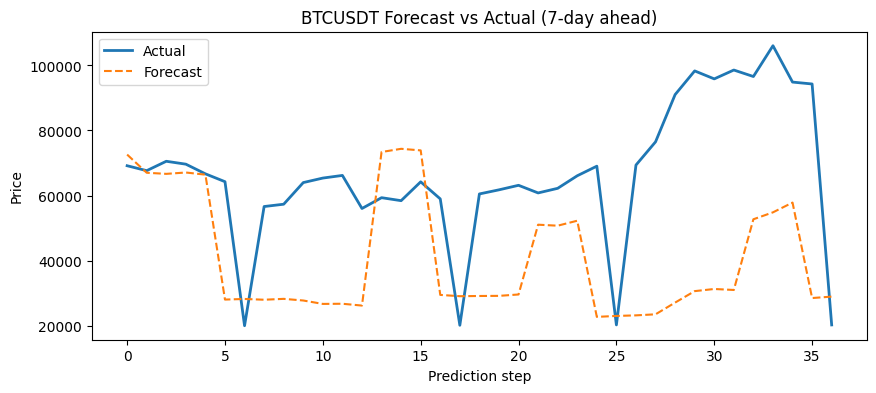


Training: ETHUSDT
ETHUSDT RMSE: 1269.4626584004602


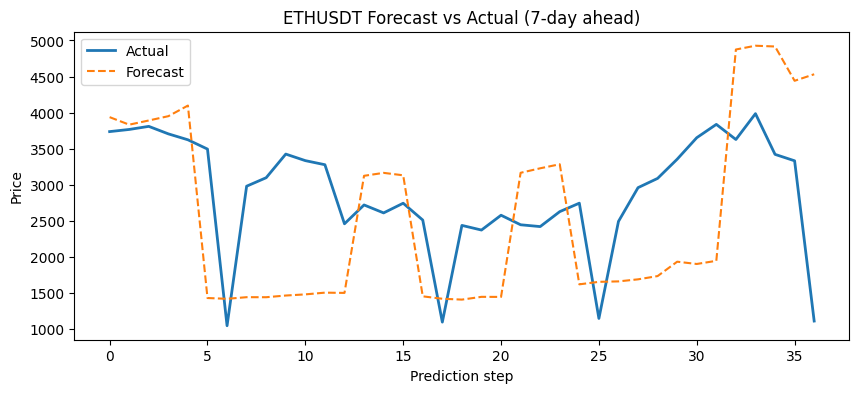


Training: SOLUSDT
SOLUSDT RMSE: 112.78144935719983


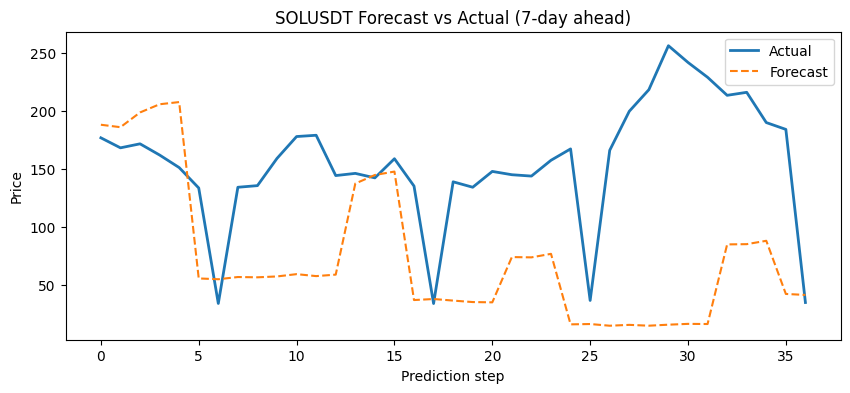


Training: TRXUSDT
TRXUSDT RMSE: 0.09454966702386039


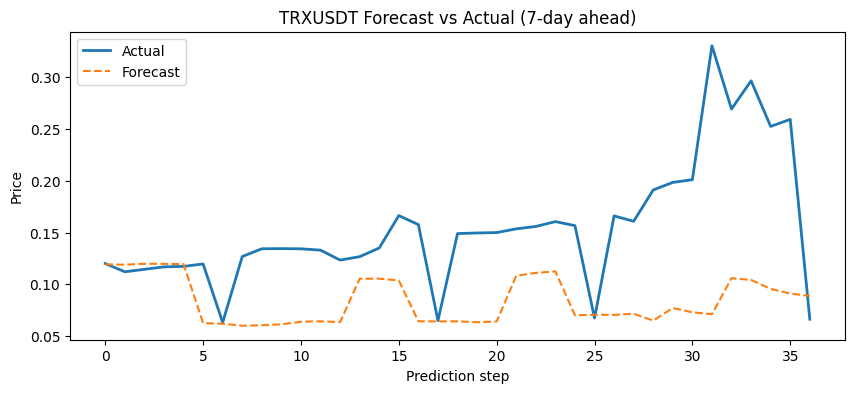


Training: XRPUSDT
XRPUSDT RMSE: 0.600473540026497


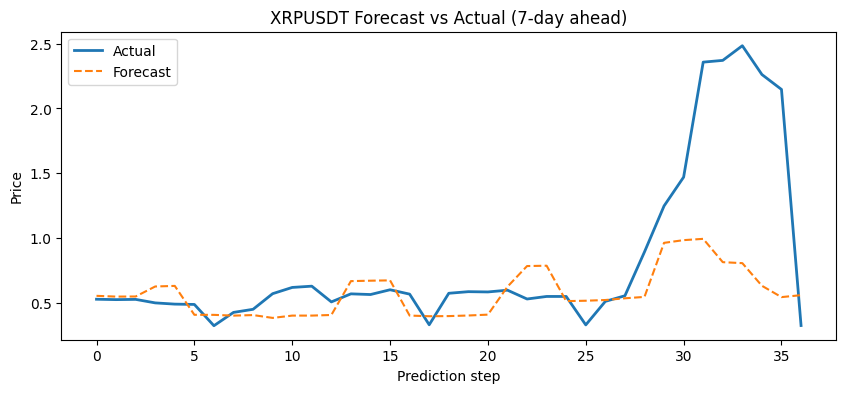

,coin,actual_price,forecast_price
0,ADAUSDT,0.4835,0.482676
1,ADAUSDT,0.4512,0.497078
2,ADAUSDT,0.4615,0.514253
3,ADAUSDT,0.4442,0.512066
4,ADAUSDT,0.4168,0.513821
...,...,...,...
32,XRPUSDT,2.3709,0.812999
33,XRPUSDT,2.4841,0.805393
34,XRPUSDT,2.2617,0.630641
35,XRPUSDT,2.1466,0.543172



RMSE Summary


,RMSE,Mean_Actual_Price,NRMSE_Percent
TRXUSDT,0.094550,0.155034,0.609866
ADAUSDT,0.232146,0.516959,0.449060
XRPUSDT,0.600474,0.813641,0.738008
SOLUSDT,112.781449,155.928108,0.723291
BCHUSDT,197.013967,372.651351,0.528682
BNBUSDT,285.736005,558.116486,0.511965
ETHUSDT,1269.462658,2895.692973,0.438397
BTCUSDT,36116.491968,66489.435946,0.543191


In [3]:
import pandas as pd
import numpy as np
import xgboost as xgb
import os
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import optuna

data_folder = "klines csv data/prices_cleaned"

HORIZON = 7
N_LAGS = 14

results = {}
all_tables = []

# Lag funct
def create_lags(df, col, n_lags):

    for i in range(1, n_lags + 1):
        df[f"{col}_lag_{i}"] = df[col].shift(i)

    return df

files = os.listdir(data_folder)

print("Files detected:", len(files))
print(files[:10])

for file in files:

    if file.startswith("."):
        continue

    coin = file.replace(".csv","")

    print("\nTraining:", coin)

    path = os.path.join(data_folder, file)

    df = pd.read_csv(path, header=None)

    df.columns = ["index","close","time"]

    df["close"] = pd.to_numeric(df["close"], errors="coerce")

    df = df.sort_values("time")
    # Returns
    df["return"] = np.log(df["close"] / df["close"].shift(1))


    # rolling vol
    df["vol_30"] = df["return"].rolling(30).std()
    df["vol_60"] = df["return"].rolling(60).std()

    df["target"] = df["return"].shift(-HORIZON)

    df = create_lags(df, "return", N_LAGS)
    df = create_lags(df, "vol_30", 10)
    df = create_lags(df, "vol_60", 10)

    df = df.dropna().reset_index(drop=True)

    X = df.drop(columns=["target","close","time"])
    y = df["target"]

    split = int(len(df) * 0.8)

    X_train = X.iloc[:split]
    X_test = X.iloc[split:]

    y_train = y.iloc[:split]
    y_test = y.iloc[split:]
    # Model
    model = xgb.XGBRegressor(

        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42

    )

    model.fit(X_train, y_train)

    preds_return = []
    actual_return = []

    for i in range(0, len(X_test), 7):

        if i >= len(X_test):
            break

        pred = model.predict(X_test.iloc[i:i+1])[0]

        preds_return.append(pred)

        actual_return.append(y_test.iloc[i])


    actual_price = df["close"].iloc[split::7].values[:len(preds_return)]

    start_price = df["close"].iloc[split]

    preds_price = []

    price = start_price

    for r in preds_return:

        price = price * np.exp(r)

        preds_price.append(price)


    rmse = np.sqrt(mean_squared_error(actual_price, preds_price))
    mean_actual_price = np.mean(actual_price)
    nrmse_percent = (rmse / mean_actual_price)

    results[coin] = {
        "RMSE": rmse,
        "Mean_Actual_Price": mean_actual_price,
        "NRMSE_Percent": nrmse_percent
    }

    print(f"{coin} RMSE:", rmse)



    table = pd.DataFrame({

        "coin": coin,
        "actual_price": actual_price,
        "forecast_price": preds_price

    })

    all_tables.append(table)



    plt.figure(figsize=(10,4))

    plt.plot(actual_price, label="Actual", linewidth=2)
    plt.plot(preds_price, label="Forecast", linestyle="--")

    plt.title(f"{coin} Forecast vs Actual (7-day ahead)")
    plt.xlabel("Prediction step")
    plt.ylabel("Price")

    plt.legend()

    plt.show()



final_table = pd.concat(all_tables)

display(final_table)

final_table.to_csv("12 XGBoost results/xgb_feature_forecasts.csv", index=False)


rmse_table = pd.DataFrame.from_dict(results, orient="index")
rmse_table = rmse_table.sort_values("RMSE")

print("\nRMSE Summary")
display(rmse_table)
rmse_table.to_csv("12 XGBoost results/xgb_feature_rmses.csv", index=True)

## Model 3 — XGBoost Bayesian Optimised (BO)


Training: ADAUSDT


C:\Users\ameli\AppData\Local\Temp\ipykernel_22124\3506587061.py:48: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"], errors="coerce")
[I 2026-04-19 15:18:58,593] A new study created in memory with name: no-name-a9e4e5f5-76ba-4534-a99e-91c805c29be8


Features used (17 total):
  - Price lags: 14 features
  - Volatility features: 1 features
  - Other features: 2 features
Training samples: 810, Validation samples: 270, Test samples: 270


Best trial: 0. Best value: 0.329311:   3%|▎         | 1/30 [00:00<00:05,  5.16it/s]

[I 2026-04-19 15:18:58,785] Trial 0 finished with value: 0.32931075583807734 and parameters: {'n_estimators': 367, 'max_depth': 6, 'learning_rate': 0.06521423441072262, 'subsample': 0.9423619553440564, 'colsample_bytree': 0.5578877528550196, 'gamma': 4.503042535950077, 'reg_alpha': 0.4451056186406699, 'reg_lambda': 4.150021607608819}. Best is trial 0 with value: 0.32931075583807734.


...

[I 2026-04-19 15:19:05,912] Trial 27 finished with value: 0.23986825809155615 and parameters: {'n_estimators': 472, 'max_depth': 9, 'learning_rate': 0.15764096465099967, 'subsample': 0.8628594476257787, 'colsample_bytree': 0.9573105047699966, 'gamma': 0.3491020182043599, 'reg_alpha': 1.8333311434428903, 'reg_lambda': 1.9791433106275729}. Best is trial 12 with value: 0.20561915490305255.


Best trial: 12. Best value: 0.205619:  97%|█████████▋| 29/30 [00:07<00:00,  3.23it/s]

[I 2026-04-19 15:19:06,229] Trial 28 finished with value: 0.2227385706255724 and parameters: {'n_estimators': 428, 'max_depth': 8, 'learning_rate': 0.11587423448464204, 'subsample': 0.7332107635050149, 'colsample_bytree': 0.822736945993246, 'gamma': 0.012549172391868424, 'reg_alpha': 3.10487036029764, 'reg_lambda': 0.5254230090132288}. Best is trial 12 with value: 0.20561915490305255.


Best trial: 12. Best value: 0.205619: 100%|██████████| 30/30 [00:07<00:00,  3.77it/s]


[I 2026-04-19 15:19:06,547] Trial 29 finished with value: 0.254695435685746 and parameters: {'n_estimators': 378, 'max_depth': 10, 'learning_rate': 0.0713717704149126, 'subsample': 0.5604754977146649, 'colsample_bytree': 0.9959154395081017, 'gamma': 0.7281812761484692, 'reg_alpha': 0.6984079782424195, 'reg_lambda': 2.3044363327217208}. Best is trial 12 with value: 0.20561915490305255.
Best params: {'n_estimators': 492, 'max_depth': 10, 'learning_rate': 0.10368178286670532, 'subsample': 0.7188348756519822, 'colsample_bytree': 0.9457819435471992, 'gamma': 0.0412794948538862, 'reg_alpha': 1.6710955847832225, 'reg_lambda': 1.4249507524386937}

Top 10 Most Important Features:
   feature  importance
     lag_2    0.390299
     close    0.376635
     lag_3    0.066218
     lag_1    0.060241
volatility    0.016649
     lag_4    0.016017
log_return    0.014691
    lag_12    0.014521
    lag_10    0.012165
    lag_14    0.011189

ADAUSDT RMSE: 0.084306


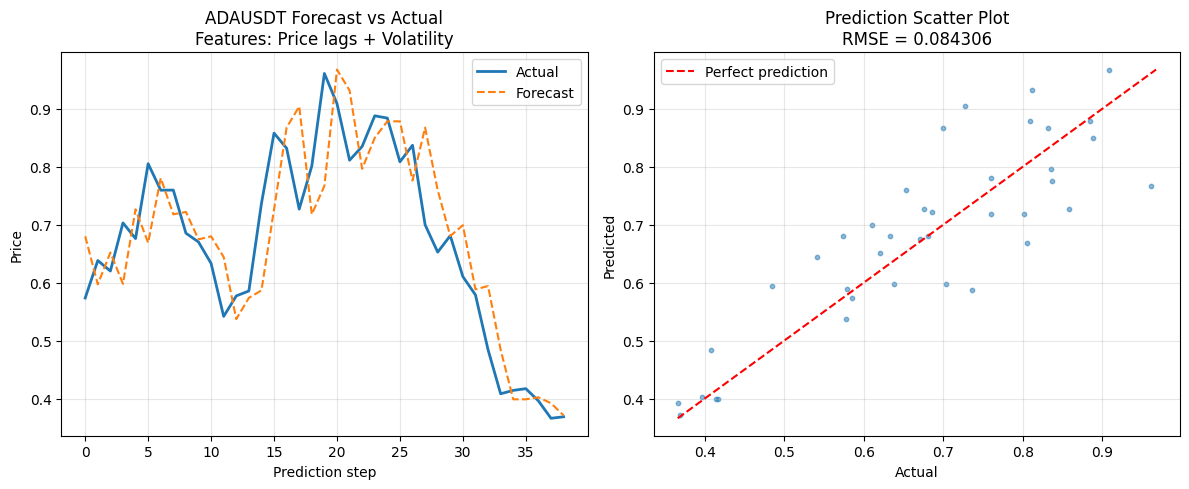

C:\Users\ameli\AppData\Local\Temp\ipykernel_22124\3506587061.py:48: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"], errors="coerce")
[I 2026-04-19 15:19:07,766] A new study created in memory with name: no-name-5ab577ea-2038-4f96-9164-a67242d2ac56



Training: BCHUSDT
Features used (17 total):
  - Price lags: 14 features
  - Volatility features: 1 features
  - Other features: 2 features
Training samples: 810, Validation samples: 270, Test samples: 270


Best trial: 0. Best value: 59.785:   3%|▎         | 1/30 [00:01<00:32,  1.12s/it]

[I 2026-04-19 15:19:08,890] Trial 0 finished with value: 59.785005377352654 and parameters: {'n_estimators': 293, 'max_depth': 8, 'learning_rate': 0.02850947844477085, 'subsample': 0.6238825337014722, 'colsample_bytree': 0.9461041576199453, 'gamma': 3.030193900352759, 'reg_alpha': 1.0092651968111321, 'reg_lambda': 2.4995876459171296}. Best is trial 0 with value: 59.785005377352654.


Best trial: 0. Best value: 59.785:   7%|▋         | 2/30 [00:01<00:25,  1.08it/s]

...

[I 2026-04-19 15:19:22,896] Trial 26 finished with value: 61.57179391389406 and parameters: {'n_estimators': 265, 'max_depth': 6, 'learning_rate': 0.04460729355943984, 'subsample': 0.7690423705967706, 'colsample_bytree': 0.6785205827996404, 'gamma': 3.2473400184777557, 'reg_alpha': 0.49155918507834473, 'reg_lambda': 1.0610521992722675}. Best is trial 22 with value: 56.61586252780458.


Best trial: 28. Best value: 54.6234:  97%|█████████▋| 29/30 [00:15<00:00,  3.31it/s]

[I 2026-04-19 15:19:23,113] Trial 27 finished with value: 57.374754287845974 and parameters: {'n_estimators': 119, 'max_depth': 5, 'learning_rate': 0.028304912819784964, 'subsample': 0.8631063119139661, 'colsample_bytree': 0.596457142019773, 'gamma': 4.16698869092375, 'reg_alpha': 2.699162102013686, 'reg_lambda': 0.8364493529569162}. Best is trial 22 with value: 56.61586252780458.
[I 2026-04-19 15:19:23,302] Trial 28 finished with value: 54.62335457416852 and parameters: {'n_estimators': 125, 'max_depth': 4, 'learning_rate': 0.024575155240887388, 'subsample': 0.933469330443078, 'colsample_bytree': 0.6023372954312171, 'gamma': 3.9190252830378296, 'reg_alpha': 2.8714772291118553, 'reg_lambda': 2.191012840860597}. Best is trial 28 with value: 54.62335457416852.


Best trial: 28. Best value: 54.6234: 100%|██████████| 30/30 [00:15<00:00,  1.88it/s]


[I 2026-04-19 15:19:23,724] Trial 29 finished with value: 63.744974302240614 and parameters: {'n_estimators': 139, 'max_depth': 8, 'learning_rate': 0.011443461919778589, 'subsample': 0.9244134368592316, 'colsample_bytree': 0.5901790829166922, 'gamma': 2.4302736332808665, 'reg_alpha': 1.3055896622120322, 'reg_lambda': 2.1596764407020697}. Best is trial 28 with value: 54.62335457416852.
Best params: {'n_estimators': 125, 'max_depth': 4, 'learning_rate': 0.024575155240887388, 'subsample': 0.933469330443078, 'colsample_bytree': 0.6023372954312171, 'gamma': 3.9190252830378296, 'reg_alpha': 2.8714772291118553, 'reg_lambda': 2.191012840860597}

Top 10 Most Important Features:
   feature  importance
     lag_1    0.329026
     close    0.328459
     lag_3    0.110728
     lag_2    0.110005
     lag_4    0.026719
     lag_5    0.019805
    lag_10    0.009975
     lag_6    0.007907
volatility    0.007867
    lag_12    0.007530

BCHUSDT RMSE: 77.117129


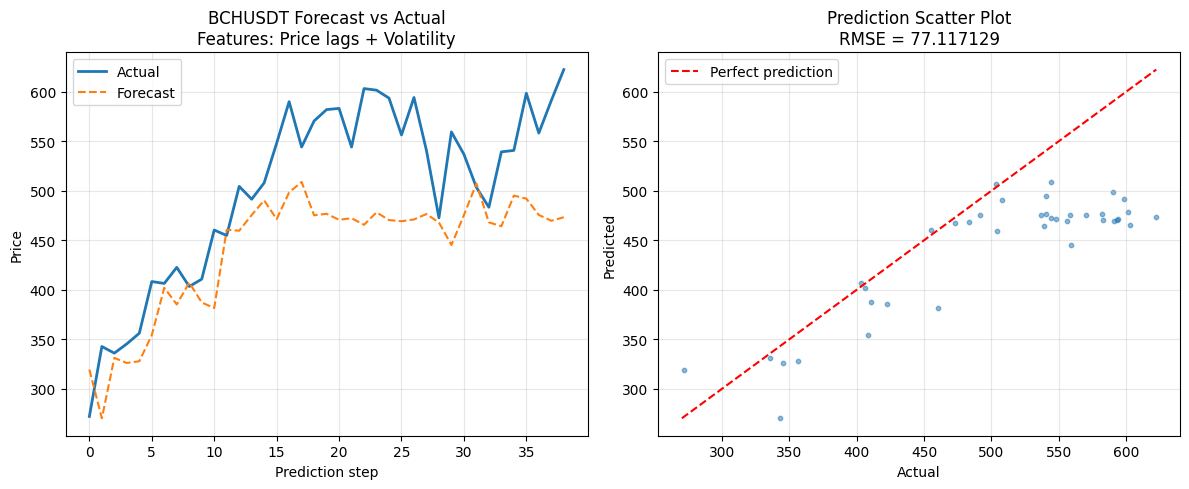

C:\Users\ameli\AppData\Local\Temp\ipykernel_22124\3506587061.py:48: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"], errors="coerce")
[I 2026-04-19 15:19:24,828] A new study created in memory with name: no-name-51ececbb-eff3-4bb5-8d10-91aa1ceefda4



Training: BNBUSDT
Features used (17 total):
  - Price lags: 14 features
  - Volatility features: 1 features
  - Other features: 2 features
Training samples: 810, Validation samples: 270, Test samples: 270


Best trial: 0. Best value: 71.1698:   3%|▎         | 1/30 [00:00<00:05,  5.33it/s]

[I 2026-04-19 15:19:25,012] Trial 0 finished with value: 71.1698246223638 and parameters: {'n_estimators': 110, 'max_depth': 5, 'learning_rate': 0.0831434400738748, 'subsample': 0.5886272254881755, 'colsample_bytree': 0.6033514622344165, 'gamma': 3.4846270831266333, 'reg_alpha': 2.8605036665439885, 'reg_lambda': 4.841054605693824}. Best is trial 0 with value: 71.1698246223638.


Best trial: 2. Best value: 68.2891:  10%|█         | 3/30 [00:00<00:05,  5.28it/s]

...

[I 2026-04-19 15:19:35,076] Trial 27 finished with value: 70.28626148031758 and parameters: {'n_estimators': 139, 'max_depth': 6, 'learning_rate': 0.14943160659786495, 'subsample': 0.8608138596000319, 'colsample_bytree': 0.6844535044307909, 'gamma': 2.528510750526843, 'reg_alpha': 3.8234252587151962, 'reg_lambda': 0.6133111641389257}. Best is trial 21 with value: 66.74599260884445.


Best trial: 21. Best value: 66.746:  97%|█████████▋| 29/30 [00:10<00:00,  3.73it/s]

[I 2026-04-19 15:19:35,331] Trial 28 finished with value: 68.55215671794149 and parameters: {'n_estimators': 130, 'max_depth': 5, 'learning_rate': 0.12227536265330534, 'subsample': 0.7778178126891757, 'colsample_bytree': 0.5746630069960348, 'gamma': 1.6951582173691593, 'reg_alpha': 3.009824964415777, 'reg_lambda': 0.309317675603471}. Best is trial 21 with value: 66.74599260884445.


Best trial: 21. Best value: 66.746: 100%|██████████| 30/30 [00:10<00:00,  2.80it/s]


[I 2026-04-19 15:19:35,540] Trial 29 finished with value: 71.87163424019121 and parameters: {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.16973800253030064, 'subsample': 0.9222477043890289, 'colsample_bytree': 0.5982673541747557, 'gamma': 3.7907328164683873, 'reg_alpha': 3.0986736621391633, 'reg_lambda': 4.955747918021185}. Best is trial 21 with value: 66.74599260884445.
Best params: {'n_estimators': 106, 'max_depth': 3, 'learning_rate': 0.17953664429114397, 'subsample': 0.6736768486068926, 'colsample_bytree': 0.5965816073073388, 'gamma': 1.8751088477666613, 'reg_alpha': 4.984291963517144, 'reg_lambda': 0.8712414163252511}

Top 10 Most Important Features:
feature  importance
  lag_1    0.652206
  close    0.269860
  lag_2    0.014905
  lag_5    0.009897
  lag_3    0.007473
 lag_11    0.006366
 lag_12    0.004815
 lag_13    0.004679
  lag_8    0.004516
  lag_6    0.004070

BNBUSDT RMSE: 208.910847


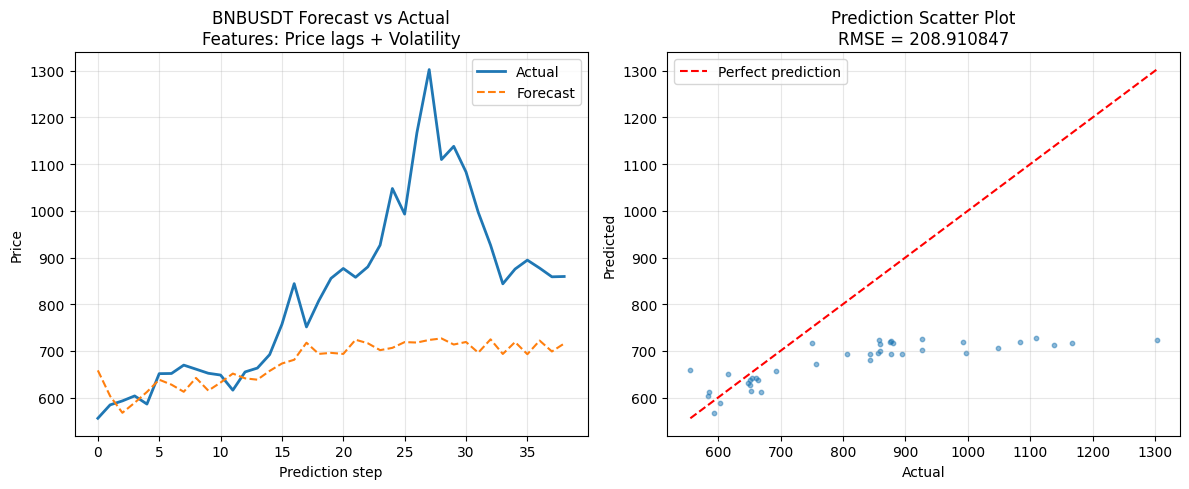

C:\Users\ameli\AppData\Local\Temp\ipykernel_22124\3506587061.py:48: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"], errors="coerce")
[I 2026-04-19 15:19:36,462] A new study created in memory with name: no-name-fd8f73ae-e0e3-43f2-8ac5-ad94ed057993



Training: BTCUSDT
Features used (17 total):
  - Price lags: 14 features
  - Volatility features: 1 features
  - Other features: 2 features
Training samples: 810, Validation samples: 270, Test samples: 270


Best trial: 0. Best value: 23981.4:   3%|▎         | 1/30 [00:00<00:22,  1.28it/s]

[I 2026-04-19 15:19:37,239] Trial 0 finished with value: 23981.431886061662 and parameters: {'n_estimators': 202, 'max_depth': 8, 'learning_rate': 0.07510945385639153, 'subsample': 0.9951761141463038, 'colsample_bytree': 0.6634922159822403, 'gamma': 1.1361484958416361, 'reg_alpha': 3.1848686224049008, 'reg_lambda': 0.2915282966904148}. Best is trial 0 with value: 23981.431886061662.


Best trial: 0. Best value: 23981.4:   7%|▋         | 2/30 [00:02<00:32,  1.18s/it]

...

[I 2026-04-19 15:19:54,263] Trial 27 finished with value: 20704.07169401743 and parameters: {'n_estimators': 216, 'max_depth': 3, 'learning_rate': 0.08798895982048784, 'subsample': 0.9581014960179653, 'colsample_bytree': 0.5577452419338733, 'gamma': 1.8365851528683033, 'reg_alpha': 0.5399957535571887, 'reg_lambda': 3.378674951998237}. Best is trial 25 with value: 20680.30498268444.


Best trial: 25. Best value: 20680.3:  97%|█████████▋| 29/30 [00:18<00:00,  3.61it/s]

[I 2026-04-19 15:19:54,495] Trial 28 finished with value: 21111.046438671383 and parameters: {'n_estimators': 191, 'max_depth': 3, 'learning_rate': 0.12012618729024337, 'subsample': 0.958459216317184, 'colsample_bytree': 0.6347375866513381, 'gamma': 1.9446960874935708, 'reg_alpha': 1.110251759312473, 'reg_lambda': 3.7063719114384392}. Best is trial 25 with value: 20680.30498268444.


Best trial: 25. Best value: 20680.3: 100%|██████████| 30/30 [00:19<00:00,  1.54it/s]


[I 2026-04-19 15:19:55,881] Trial 29 finished with value: 24313.28202103086 and parameters: {'n_estimators': 221, 'max_depth': 9, 'learning_rate': 0.06503343573838544, 'subsample': 0.9922117126922874, 'colsample_bytree': 0.6946058697610542, 'gamma': 1.1838724707450063, 'reg_alpha': 0.5428076474494521, 'reg_lambda': 3.372975375746866}. Best is trial 25 with value: 20680.30498268444.
Best params: {'n_estimators': 145, 'max_depth': 3, 'learning_rate': 0.10599287151137929, 'subsample': 0.9528425843585743, 'colsample_bytree': 0.6391004763744825, 'gamma': 1.228593316334377, 'reg_alpha': 0.4170323963995271, 'reg_lambda': 2.66277059716714}

Top 10 Most Important Features:
feature  importance
  lag_1    0.324522
  lag_4    0.134698
  lag_6    0.133639
  lag_5    0.132317
  close    0.119272
  lag_9    0.095333
 lag_10    0.024965
  lag_7    0.013609
  lag_8    0.006394
  lag_3    0.006250

BTCUSDT RMSE: 13520.184233


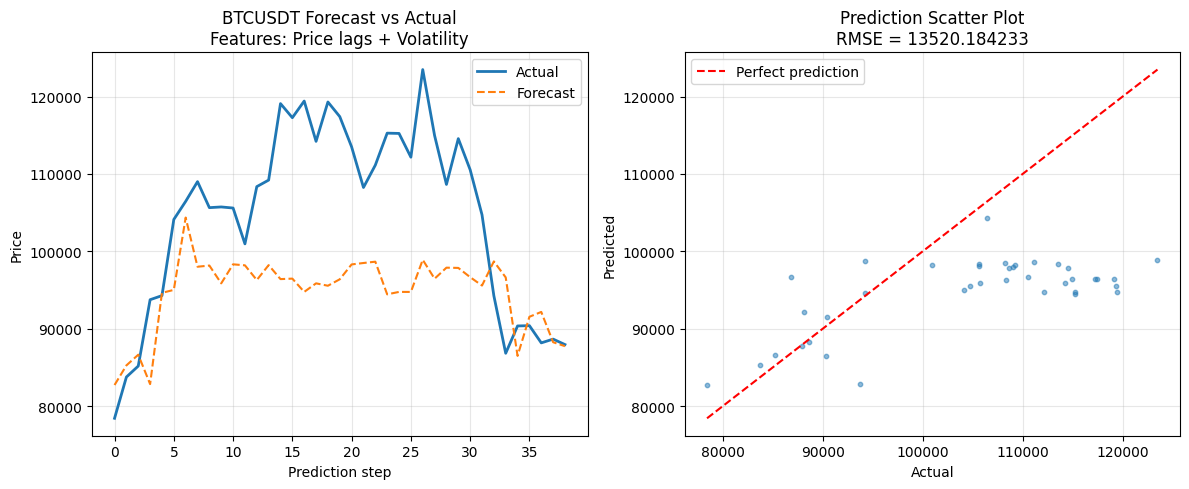

C:\Users\ameli\AppData\Local\Temp\ipykernel_22124\3506587061.py:48: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"], errors="coerce")
[I 2026-04-19 15:19:56,849] A new study created in memory with name: no-name-9ef4b4f1-3ad9-4fe5-a501-53b582be0f41



Training: ETHUSDT
Features used (17 total):
  - Price lags: 14 features
  - Volatility features: 1 features
  - Other features: 2 features
Training samples: 810, Validation samples: 270, Test samples: 270


Best trial: 0. Best value: 315.379:   3%|▎         | 1/30 [00:01<00:55,  1.91s/it]

[I 2026-04-19 15:19:58,753] Trial 0 finished with value: 315.3789175106061 and parameters: {'n_estimators': 445, 'max_depth': 9, 'learning_rate': 0.02796786358216529, 'subsample': 0.5147776707438303, 'colsample_bytree': 0.9477881441597658, 'gamma': 0.80968554499045, 'reg_alpha': 3.2150854861921245, 'reg_lambda': 1.2795466842507404}. Best is trial 0 with value: 315.3789175106061.


Best trial: 0. Best value: 315.379:   7%|▋         | 2/30 [00:02<00:37,  1.34s/it]

...

[I 2026-04-19 15:20:13,829] Trial 27 finished with value: 305.6710656035566 and parameters: {'n_estimators': 138, 'max_depth': 6, 'learning_rate': 0.048459923421687284, 'subsample': 0.9153094090080779, 'colsample_bytree': 0.6643953672530835, 'gamma': 3.182790234898657, 'reg_alpha': 1.3253118665480677, 'reg_lambda': 3.018626945263205}. Best is trial 10 with value: 291.83423352135037.


Best trial: 10. Best value: 291.834:  97%|█████████▋| 29/30 [00:17<00:00,  1.83it/s]

[I 2026-04-19 15:20:14,569] Trial 28 finished with value: 300.14440425091215 and parameters: {'n_estimators': 193, 'max_depth': 8, 'learning_rate': 0.11791299140494267, 'subsample': 0.7590345687462401, 'colsample_bytree': 0.5048939642026007, 'gamma': 2.0321021227152816, 'reg_alpha': 4.039635284144635, 'reg_lambda': 3.6245751029148394}. Best is trial 10 with value: 291.83423352135037.


Best trial: 10. Best value: 291.834: 100%|██████████| 30/30 [00:18<00:00,  1.66it/s]


[I 2026-04-19 15:20:14,883] Trial 29 finished with value: 299.5335302850834 and parameters: {'n_estimators': 124, 'max_depth': 5, 'learning_rate': 0.10673577990096977, 'subsample': 0.516124280844997, 'colsample_bytree': 0.8413933866955372, 'gamma': 1.3770316587168578, 'reg_alpha': 3.1167377972144585, 'reg_lambda': 4.180400961211868}. Best is trial 10 with value: 291.83423352135037.
Best params: {'n_estimators': 198, 'max_depth': 5, 'learning_rate': 0.15079489249824723, 'subsample': 0.7736181491095653, 'colsample_bytree': 0.5021089566494603, 'gamma': 2.3470022382040625, 'reg_alpha': 1.9758333370551266, 'reg_lambda': 4.668359572155155}

Top 10 Most Important Features:
   feature  importance
     lag_1    0.503986
     close    0.295857
     lag_2    0.076352
     lag_4    0.043609
     lag_3    0.009420
    lag_13    0.008601
    lag_11    0.007811
     lag_7    0.006609
volatility    0.006593
     lag_9    0.006040

ETHUSDT RMSE: 589.065901


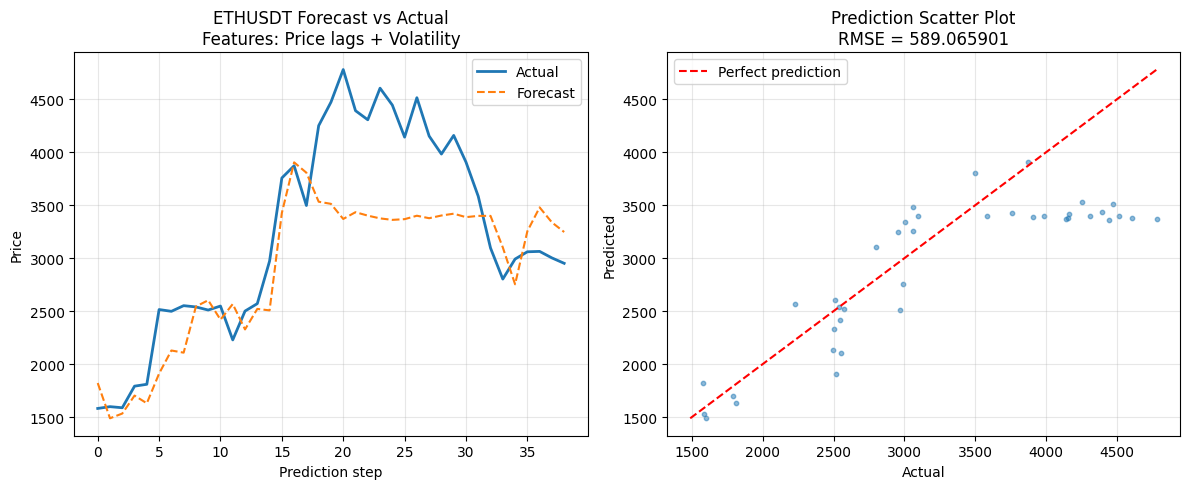

C:\Users\ameli\AppData\Local\Temp\ipykernel_22124\3506587061.py:48: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"], errors="coerce")
[I 2026-04-19 15:20:16,112] A new study created in memory with name: no-name-473cdcff-7216-4d8f-8bdf-28b2c9f77fc8



Training: SOLUSDT
Features used (17 total):
  - Price lags: 14 features
  - Volatility features: 1 features
  - Other features: 2 features
Training samples: 810, Validation samples: 270, Test samples: 270


Best trial: 0. Best value: 41.0538:   3%|▎         | 1/30 [00:00<00:12,  2.40it/s]

[I 2026-04-19 15:20:16,527] Trial 0 finished with value: 41.053804100475695 and parameters: {'n_estimators': 143, 'max_depth': 9, 'learning_rate': 0.09392121464260009, 'subsample': 0.7663964422997378, 'colsample_bytree': 0.5874617591408748, 'gamma': 2.040860903923585, 'reg_alpha': 3.5939620189692656, 'reg_lambda': 3.5540124938303927}. Best is trial 0 with value: 41.053804100475695.


Best trial: 1. Best value: 36.1753:   7%|▋         | 2/30 [00:00<00:09,  2.80it/s]

...

[I 2026-04-19 15:20:28,492] Trial 27 finished with value: 35.72128692842224 and parameters: {'n_estimators': 285, 'max_depth': 3, 'learning_rate': 0.10848487373642006, 'subsample': 0.7491237670479469, 'colsample_bytree': 0.6979089799763846, 'gamma': 1.9808233442998642, 'reg_alpha': 3.789031017933081, 'reg_lambda': 1.0459275832670085}. Best is trial 25 with value: 32.74855183026029.


Best trial: 25. Best value: 32.7486:  97%|█████████▋| 29/30 [00:12<00:00,  2.24it/s]

[I 2026-04-19 15:20:28,987] Trial 28 finished with value: 37.52388270348694 and parameters: {'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.085826773901445, 'subsample': 0.9594415286770747, 'colsample_bytree': 0.7698293501847794, 'gamma': 2.359720177721712, 'reg_alpha': 1.7609429058817863, 'reg_lambda': 1.4468580414526073}. Best is trial 25 with value: 32.74855183026029.


Best trial: 25. Best value: 32.7486: 100%|██████████| 30/30 [00:13<00:00,  2.24it/s]


[I 2026-04-19 15:20:29,492] Trial 29 finished with value: 38.246906782986265 and parameters: {'n_estimators': 450, 'max_depth': 5, 'learning_rate': 0.07421989357797723, 'subsample': 0.766050454558557, 'colsample_bytree': 0.5743726179047999, 'gamma': 2.8800631048512684, 'reg_alpha': 0.4245638078561198, 'reg_lambda': 2.951469879803269}. Best is trial 25 with value: 32.74855183026029.
Best params: {'n_estimators': 459, 'max_depth': 3, 'learning_rate': 0.17101460187618417, 'subsample': 0.8199938445306396, 'colsample_bytree': 0.6512022497983229, 'gamma': 1.3385065364878859, 'reg_alpha': 0.004867473594040474, 'reg_lambda': 0.9935143351395873}

Top 10 Most Important Features:
feature  importance
  lag_1    0.523661
  close    0.254732
  lag_9    0.112281
  lag_2    0.023201
  lag_7    0.022721
  lag_4    0.013784
  lag_5    0.009188
  lag_6    0.007854
  lag_3    0.005256
 lag_14    0.004483

SOLUSDT RMSE: 22.333331


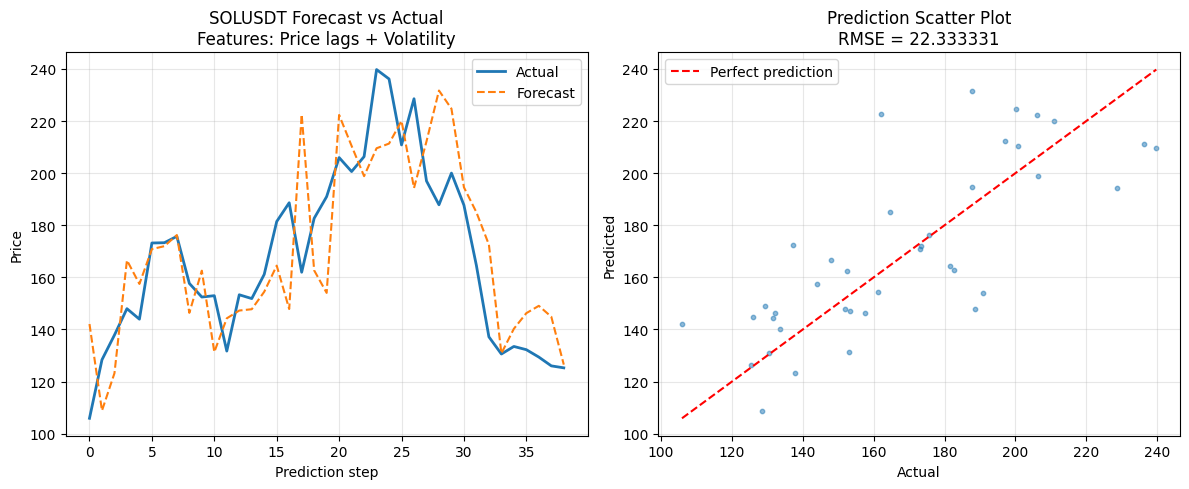

C:\Users\ameli\AppData\Local\Temp\ipykernel_22124\3506587061.py:48: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"], errors="coerce")
[I 2026-04-19 15:20:30,786] A new study created in memory with name: no-name-df125139-8bf4-44b5-b59d-b867f0c6a6f6



Training: TRXUSDT
Features used (17 total):
  - Price lags: 14 features
  - Volatility features: 1 features
  - Other features: 2 features
Training samples: 810, Validation samples: 270, Test samples: 270


Best trial: 0. Best value: 0.12603:   7%|▋         | 2/30 [00:00<00:06,  4.48it/s]

[I 2026-04-19 15:20:31,074] Trial 0 finished with value: 0.12602966170678476 and parameters: {'n_estimators': 348, 'max_depth': 9, 'learning_rate': 0.136039392663174, 'subsample': 0.914902442963444, 'colsample_bytree': 0.8578631783642523, 'gamma': 3.494694824066136, 'reg_alpha': 4.614745669358589, 'reg_lambda': 3.85193984078526}. Best is trial 0 with value: 0.12602966170678476.
[I 2026-04-19 15:20:31,249] Trial 1 finished with value: 0.12602966170678476 and parameters: {'n_estimators': 386, 'max_depth': 6, 'learning_rate': 0.07430619991186338, 'subsample': 0.7947317398388423, 'colsample_bytree': 0.6327394122430181, 'gamma': 4.001302164321068, 'reg_alpha': 3.1880004043007575, 'reg_lambda': 2.202455140593935}. Best is trial 0 with value: 0.12602966170678476.


Best trial: 0. Best value: 0.12603:  10%|█         | 3/30 [00:00<00:06,  4.39it/s]

...

[I 2026-04-19 15:20:36,072] Trial 26 finished with value: 0.12602966170678476 and parameters: {'n_estimators': 169, 'max_depth': 4, 'learning_rate': 0.06885471248822922, 'subsample': 0.6250305935667934, 'colsample_bytree': 0.7827026723991029, 'gamma': 2.8333456066903002, 'reg_alpha': 0.9009040836967698, 'reg_lambda': 0.02752520768337441}. Best is trial 8 with value: 0.12576113057160013.


Best trial: 8. Best value: 0.125761:  97%|█████████▋| 29/30 [00:05<00:00,  5.32it/s]

[I 2026-04-19 15:20:36,311] Trial 27 finished with value: 0.12602966170678476 and parameters: {'n_estimators': 279, 'max_depth': 4, 'learning_rate': 0.011091765120119612, 'subsample': 0.7933056487340677, 'colsample_bytree': 0.895103316819174, 'gamma': 3.4750103939328616, 'reg_alpha': 1.6922676563431944, 'reg_lambda': 0.40809221608541063}. Best is trial 8 with value: 0.12576113057160013.
[I 2026-04-19 15:20:36,473] Trial 28 finished with value: 0.126031236061882 and parameters: {'n_estimators': 137, 'max_depth': 5, 'learning_rate': 0.06328170146713408, 'subsample': 0.6962139661334897, 'colsample_bytree': 0.9620591676000604, 'gamma': 2.2573778939646116, 'reg_alpha': 0.42648354613012796, 'reg_lambda': 2.0987236178541595}. Best is trial 8 with value: 0.12576113057160013.


Best trial: 8. Best value: 0.125761: 100%|██████████| 30/30 [00:05<00:00,  5.04it/s]


[I 2026-04-19 15:20:36,738] Trial 29 finished with value: 0.12602966170678476 and parameters: {'n_estimators': 358, 'max_depth': 9, 'learning_rate': 0.15420788264150756, 'subsample': 0.9943867163779005, 'colsample_bytree': 0.8379196267782263, 'gamma': 3.780471899636657, 'reg_alpha': 4.344412465780783, 'reg_lambda': 4.332480340395012}. Best is trial 8 with value: 0.12576113057160013.
Best params: {'n_estimators': 310, 'max_depth': 7, 'learning_rate': 0.10954025703738242, 'subsample': 0.5863064995548346, 'colsample_bytree': 0.8427703420499766, 'gamma': 3.9960283558379714, 'reg_alpha': 0.29356994945167636, 'reg_lambda': 1.0136103871270796}

Top 10 Most Important Features:
   feature  importance
     close         0.0
log_return         0.0
volatility         0.0
     lag_1         0.0
     lag_2         0.0
     lag_3         0.0
     lag_4         0.0
     lag_5         0.0
     lag_6         0.0
     lag_7         0.0

TRXUSDT RMSE: 0.186578


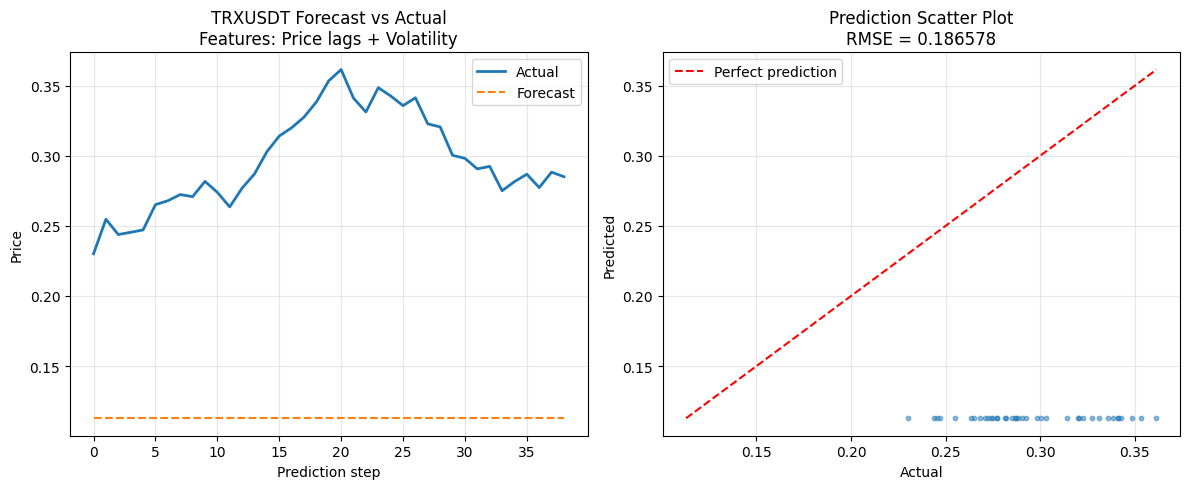

C:\Users\ameli\AppData\Local\Temp\ipykernel_22124\3506587061.py:48: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"], errors="coerce")
[I 2026-04-19 15:20:37,695] A new study created in memory with name: no-name-9186a8ef-f892-4fa8-9d89-467f78dca460



Training: XRPUSDT
Features used (17 total):
  - Price lags: 14 features
  - Volatility features: 1 features
  - Other features: 2 features
Training samples: 810, Validation samples: 270, Test samples: 270


Best trial: 0. Best value: 1.39289:   3%|▎         | 1/30 [00:00<00:03,  7.86it/s]

[I 2026-04-19 15:20:37,819] Trial 0 finished with value: 1.3928850417872214 and parameters: {'n_estimators': 195, 'max_depth': 7, 'learning_rate': 0.04278066062117195, 'subsample': 0.7373901526513378, 'colsample_bytree': 0.9163920380864734, 'gamma': 2.682959213675493, 'reg_alpha': 2.459145083079103, 'reg_lambda': 3.0562701154128207}. Best is trial 0 with value: 1.3928850417872214.


Best trial: 1. Best value: 1.33265:  10%|█         | 3/30 [00:00<00:04,  5.67it/s]

...

[I 2026-04-19 15:20:43,411] Trial 25 finished with value: 1.3283903452245045 and parameters: {'n_estimators': 326, 'max_depth': 5, 'learning_rate': 0.1325666339273226, 'subsample': 0.9515616222293528, 'colsample_bytree': 0.8502859802730548, 'gamma': 0.330146633688858, 'reg_alpha': 0.08214037388809872, 'reg_lambda': 3.689525463523068}. Best is trial 18 with value: 1.2700750822127338.
[I 2026-04-19 15:20:43,556] Trial 26 finished with value: 1.3688202568960506 and parameters: {'n_estimators': 138, 'max_depth': 4, 'learning_rate': 0.09731512775038786, 'subsample': 0.7648021668788233, 'colsample_bytree': 0.938611043373553, 'gamma': 1.4662290757262222, 'reg_alpha': 0.8213098740002077, 'reg_lambda': 3.044009123425743}. Best is trial 18 with value: 1.2700750822127338.


Best trial: 18. Best value: 1.27008:  97%|█████████▋| 29/30 [00:06<00:00,  5.27it/s]

[I 2026-04-19 15:20:43,779] Trial 27 finished with value: 1.344012866556893 and parameters: {'n_estimators': 364, 'max_depth': 8, 'learning_rate': 0.15806872823883106, 'subsample': 0.8786665737874519, 'colsample_bytree': 0.5709634027281469, 'gamma': 0.7491802722170406, 'reg_alpha': 0.4132998944260589, 'reg_lambda': 4.98951597774804}. Best is trial 18 with value: 1.2700750822127338.
[I 2026-04-19 15:20:43,955] Trial 28 finished with value: 1.3981375909013873 and parameters: {'n_estimators': 273, 'max_depth': 5, 'learning_rate': 0.11658654147837798, 'subsample': 0.826551365104395, 'colsample_bytree': 0.7765313066933006, 'gamma': 4.916313764686836, 'reg_alpha': 1.880854384779126, 'reg_lambda': 4.248168730283891}. Best is trial 18 with value: 1.2700750822127338.


Best trial: 18. Best value: 1.27008: 100%|██████████| 30/30 [00:06<00:00,  4.67it/s]


[I 2026-04-19 15:20:44,116] Trial 29 finished with value: 1.36820863311614 and parameters: {'n_estimators': 203, 'max_depth': 6, 'learning_rate': 0.04127687302689334, 'subsample': 0.7355114897072192, 'colsample_bytree': 0.8064278336007384, 'gamma': 1.0033409896215493, 'reg_alpha': 2.4644825203986627, 'reg_lambda': 2.0348605760905008}. Best is trial 18 with value: 1.2700750822127338.
Best params: {'n_estimators': 104, 'max_depth': 4, 'learning_rate': 0.11231597784772089, 'subsample': 0.9043703239983627, 'colsample_bytree': 0.7862339197667978, 'gamma': 0.0042204549564059946, 'reg_alpha': 0.01150108088112356, 'reg_lambda': 4.297544624081201}

Top 10 Most Important Features:
   feature  importance
     lag_1    0.614492
     close    0.304603
     lag_3    0.023732
     lag_2    0.018502
     lag_7    0.007042
     lag_9    0.004112
log_return    0.003391
    lag_11    0.003346
    lag_12    0.002761
    lag_13    0.002720

XRPUSDT RMSE: 0.381681


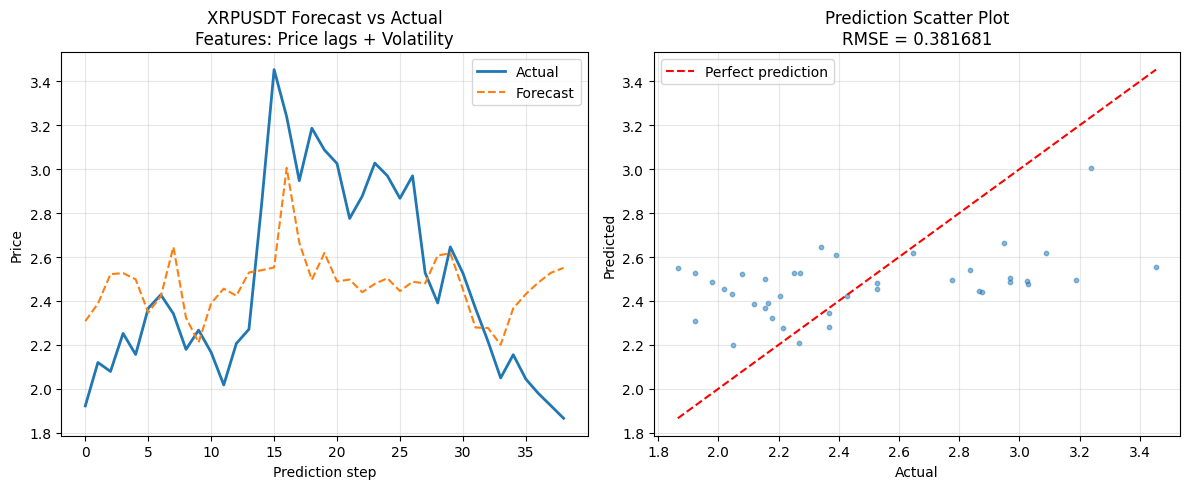


RMSE SUMMARY
                 RMSE  Mean_Actual_Price  NRMSE_Percent
ADAUSDT      0.084306           0.671769       0.125498
TRXUSDT      0.186578           0.296315       0.629661
XRPUSDT      0.381681           2.480085       0.153899
SOLUSDT     22.333331         167.505128       0.133329
BCHUSDT     77.117129         502.102564       0.153588
BNBUSDT    208.910847         820.774615       0.254529
ETHUSDT    589.065901        3219.931282       0.182944
BTCUSDT  13520.184233      104518.519744       0.129357

SUMMARY STATISTICS
Mean RMSE: 1802.283001
Median RMSE: 49.725230
Mean NRMSE (%): 0.2204%
Median NRMSE (%): 0.1537%
Best RMSE: 0.084306 (ADAUSDT)
Worst RMSE: 13520.184233 (BTCUSDT)


In [4]:
import pandas as pd
import numpy as np
import xgboost as xgb
import os
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import optuna

data_folder = "klines csv data/prices_cleaned"
HORIZON = 7
N_LAGS = 14
VOLATILITY_WINDOW = 7

results = {}
all_tables = []

def create_features(df):
    df = df.copy()

    # log return
    df["log_return"] = np.log(df["close"] / df["close"].shift(1))

    # volatility
    df["volatility"] = df["log_return"].rolling(window=VOLATILITY_WINDOW).std()

    # lagged prices only
    for i in range(1, N_LAGS + 1):
        df[f"lag_{i}"] = df["close"].shift(i)

    return df

files = os.listdir(data_folder)

for file in files:

    if file.startswith("."):
        continue

    coin = file.replace(".csv", "")
    print("\nTraining:", coin)

    path = os.path.join(data_folder, file)

    df = pd.read_csv(path, header=None)
    df.columns = ["index", "close", "time"]

    df["close"] = pd.to_numeric(df["close"], errors="coerce")
    df["time"] = pd.to_datetime(df["time"], errors="coerce")
    df = df.sort_values("time")
    df = df[["close"]]

    # tiny coins
    tiny_price = df["close"].median() < 0.01

    if tiny_price:
        print("Tiny price detected → using log price")
        df["close"] = np.log(df["close"])

    # add features: price lags + volatility only
    df = create_features(df)

    # target = future closing price HORIZON steps ahead
    df["target"] = df["close"].shift(-HORIZON)

    # drop rows with NaN
    df = df.dropna().reset_index(drop=True)

    # exclude target, keep everything else
    X = df.drop(columns=["target"])
    y = df["target"]

    split1 = int(len(df) * 0.6)
    split2 = int(len(df) * 0.8)

    X_train = X.iloc[:split1]
    X_val   = X.iloc[split1:split2]
    X_test  = X.iloc[split2:]

    y_train = y.iloc[:split1]
    y_val   = y.iloc[split1:split2]
    y_test  = y.iloc[split2:]

    print(f"Features used ({len(X.columns)} total):")
    price_lags = [col for col in X.columns if col.startswith("lag_")]
    vol_features = [col for col in X.columns if "vol" in col.lower()]
    other_features = [col for col in X.columns if col not in price_lags and col not in vol_features]

    print(f"  - Price lags: {len(price_lags)} features")
    print(f"  - Volatility features: {len(vol_features)} features")
    print(f"  - Other features: {len(other_features)} features")
    print(f"Training samples: {len(X_train)}, Validation samples: {len(X_val)}, Test samples: {len(X_test)}")

    # Bayesian Optimisation
    def objective(trial):

        params = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 500),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "gamma": trial.suggest_float("gamma", 0, 5),
            "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
            "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
            "objective": "reg:squarederror",
            "random_state": 42
        }

        model = xgb.XGBRegressor(**params)
        model.fit(X_train, y_train, verbose=False)

        preds = model.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, preds))

        return rmse

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=30, show_progress_bar=True)

    best_params = study.best_params
    print("Best params:", best_params)

    model = xgb.XGBRegressor(
        **best_params,
        objective="reg:squarederror",
        random_state=42
    )

    X_train_full = pd.concat([X_train, X_val], axis=0)
    y_train_full = pd.concat([y_train, y_val], axis=0)

    model.fit(X_train_full, y_train_full, verbose=False)

    feature_importance = pd.DataFrame({
        "feature": X.columns,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=False)

    print("\nTop 10 Most Important Features:")
    print(feature_importance.head(10).to_string(index=False))

    preds = []
    actual = []

    for i in range(0, len(X_test), 7):

        if i >= len(X_test):
            break

        pred = model.predict(X_test.iloc[i:i+1])[0]

        if tiny_price:
            preds.append(np.exp(pred))
            actual.append(np.exp(y_test.iloc[i]))
        else:
            preds.append(pred)
            actual.append(y_test.iloc[i])

    rmse = np.sqrt(mean_squared_error(actual, preds))
    mean_actual_price = np.mean(actual)
    nrmse_percent = (rmse / mean_actual_price)

    results[coin] = {
        "RMSE": rmse,
        "Mean_Actual_Price": mean_actual_price,
        "NRMSE_Percent": nrmse_percent
    }

    print(f"\n{coin} RMSE: {rmse:.6f}")

    table = pd.DataFrame({
        "coin": coin,
        "actual": actual,
        "forecast": preds
    })

    all_tables.append(table)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(actual, label="Actual", linewidth=2)
    plt.plot(preds, label="Forecast", linestyle="--")
    plt.title(f"{coin} Forecast vs Actual\nFeatures: Price lags + Volatility")
    plt.xlabel("Prediction step")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.scatter(actual, preds, alpha=0.5, s=10)
    min_val = min(min(actual), min(preds))
    max_val = max(max(actual), max(preds))
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label="Perfect prediction")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"Prediction Scatter Plot\nRMSE = {rmse:.6f}")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

final_table = pd.concat(all_tables, ignore_index=True)
final_table.to_csv("12 XGBoost results/xgboost_forecasts_BO_price_vol.csv", index=False)

rmse_table = pd.DataFrame.from_dict(results, orient="index")
rmse_table = rmse_table.sort_values("RMSE")

print("\n" + "="*60)
print("RMSE SUMMARY")
print("="*60)
print(rmse_table)
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)
print(f"Mean RMSE: {rmse_table['RMSE'].mean():.6f}")
print(f"Median RMSE: {rmse_table['RMSE'].median():.6f}")
print(f"Mean NRMSE (%): {rmse_table['NRMSE_Percent'].mean():.4f}%")
print(f"Median NRMSE (%): {rmse_table['NRMSE_Percent'].median():.4f}%")
print(f"Best RMSE: {rmse_table['RMSE'].min():.6f} ({rmse_table.index[rmse_table['RMSE'].argmin()]})")
print(f"Worst RMSE: {rmse_table['RMSE'].max():.6f} ({rmse_table.index[rmse_table['RMSE'].argmax()]})")

rmse_table.to_csv("12 XGBoost results/xgboost_rmse_summary_BO_price_vol.csv")
